In [1]:
# Import required libraries for data handling, visualization, and model building

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [2]:
# Load the raw Chicago crime dataset

file_path = "../data/raw/Crimes_-_2001_to_Present_20260902.csv"

df = pd.read_csv(
    file_path,
    low_memory=False
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (759290, 22)


In [3]:
# Display the first five records to understand the dataset structure

df.head()

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,14070466,JJ540292,12/31/2025 02:30:00 PM,001XX W 112TH PL,0910,MOTOR VEHICLE THEFT,AUTOMOBILE,STREET,False,False,...,9.0,49.0,07,1177249.0,1830354.0,2025,03/14/2026 03:41:39 PM,41.689820,-87.626713,"(41.689820475, -87.626712685)"
1,14070469,JJ540385,12/31/2025 02:30:00 PM,048XX S LAKE PARK AVE,0560,ASSAULT,SIMPLE,STREET,False,False,...,4.0,39.0,08A,1186953.0,1873098.0,2025,03/14/2026 03:41:39 PM,41.806890,-87.589834,"(41.806890268, -87.589834384)"
2,14070549,JJ540301,12/31/2025 02:30:00 PM,106XX S AVENUE M,0486,BATTERY,DOMESTIC BATTERY SIMPLE,APARTMENT,False,True,...,10.0,52.0,08B,1201519.0,1835022.0,2025,03/14/2026 03:41:39 PM,41.702049,-87.537704,"(41.702049219, -87.53770369)"
3,14078959,JK109689,12/31/2025 02:30:00 PM,038XX S VINCENNES AVE,0820,THEFT,$500 AND UNDER,APARTMENT,False,False,...,4.0,35.0,06,1180774.0,1879690.0,2025,03/14/2026 03:41:39 PM,41.825124,-87.612294,"(41.825123682, -87.61229385)"
4,14070546,JJ540340,12/31/2025 02:24:00 PM,010XX S MICHIGAN AVE,1330,CRIMINAL TRESPASS,TO LAND,APARTMENT,True,False,...,4.0,32.0,26,1177416.0,1895928.0,2025,03/14/2026 03:41:39 PM,41.869759,-87.624121,"(41.86975858, -87.624121338)"


In [4]:
# Display all column names available in the dataset

print(df.columns.tolist())

['ID', 'Case Number', 'Date', 'Block', 'IUCR', 'Primary Type', 'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat', 'District', 'Ward', 'Community Area', 'FBI Code', 'X Coordinate', 'Y Coordinate', 'Year', 'Updated On', 'Latitude', 'Longitude', 'Location']


In [5]:
# Check the number and distribution of the original crime types

print("Number of crime types:", df["Primary Type"].nunique())

print("\nCrime types:")
print(df["Primary Type"].value_counts())

Number of crime types: 31

Crime types:
Primary Type
THEFT                                173112
BATTERY                              132836
CRIMINAL DAMAGE                       84730
MOTOR VEHICLE THEFT                   68162
ASSAULT                               67644
OTHER OFFENSE                         49631
DECEPTIVE PRACTICE                    49097
ROBBERY                               25952
BURGLARY                              25647
WEAPONS VIOLATION                     21832
NARCOTICS                             18863
CRIMINAL TRESPASS                     14992
OFFENSE INVOLVING CHILDREN             4977
CRIMINAL SEXUAL ASSAULT                4969
SEX OFFENSE                            3961
PUBLIC PEACE VIOLATION                 2895
INTERFERENCE WITH PUBLIC OFFICER       2193
HOMICIDE                               1669
STALKING                               1626
ARSON                                  1368
PROSTITUTION                            705
CONCEALED CARRY LICENSE

In [6]:
# Group similar crime types into broader crime categories
# This reduces the number of target classes for classification

crime_groups = {

    "Theft & Deception": [
        "THEFT",
        "DECEPTIVE PRACTICE"
    ],

    "Violent Crime": [
        "BATTERY",
        "ASSAULT",
        "ROBBERY",
        "HOMICIDE",
        "KIDNAPPING"
    ],

    "Property Damage & Burglary": [
        "CRIMINAL DAMAGE",
        "BURGLARY",
        "ARSON"
    ],

    "Vehicle Crime": [
        "MOTOR VEHICLE THEFT"
    ],

    "Drugs & Weapons": [
        "NARCOTICS",
        "OTHER NARCOTIC VIOLATION",
        "WEAPONS VIOLATION",
        "CONCEALED CARRY LICENSE VIOLATION"
    ],

    "Public Order & Official": [
        "PUBLIC PEACE VIOLATION",
        "PROSTITUTION",
        "LIQUOR LAW VIOLATION",
        "INTERFERENCE WITH PUBLIC OFFICER",
        "GAMBLING",
        "PUBLIC INDECENCY",
        "OBSCENITY"
    ],

    "Trespass & Other Offense": [
        "CRIMINAL TRESPASS",
        "OTHER OFFENSE",
        "NON-CRIMINAL"
    ],

    "Sexual, Child & Threat": [
        "CRIMINAL SEXUAL ASSAULT",
        "SEX OFFENSE",
        "OFFENSE INVOLVING CHILDREN",
        "STALKING",
        "INTIMIDATION",
        "HUMAN TRAFFICKING"
    ]
}

In [7]:
# Create a mapping from each original crime type to its broader crime group

crime_to_group = {}

for group, crimes in crime_groups.items():
    for crime in crimes:
        crime_to_group[crime] = group

print(crime_to_group)

{'THEFT': 'Theft & Deception', 'DECEPTIVE PRACTICE': 'Theft & Deception', 'BATTERY': 'Violent Crime', 'ASSAULT': 'Violent Crime', 'ROBBERY': 'Violent Crime', 'HOMICIDE': 'Violent Crime', 'KIDNAPPING': 'Violent Crime', 'CRIMINAL DAMAGE': 'Property Damage & Burglary', 'BURGLARY': 'Property Damage & Burglary', 'ARSON': 'Property Damage & Burglary', 'MOTOR VEHICLE THEFT': 'Vehicle Crime', 'NARCOTICS': 'Drugs & Weapons', 'OTHER NARCOTIC VIOLATION': 'Drugs & Weapons', 'WEAPONS VIOLATION': 'Drugs & Weapons', 'CONCEALED CARRY LICENSE VIOLATION': 'Drugs & Weapons', 'PUBLIC PEACE VIOLATION': 'Public Order & Official', 'PROSTITUTION': 'Public Order & Official', 'LIQUOR LAW VIOLATION': 'Public Order & Official', 'INTERFERENCE WITH PUBLIC OFFICER': 'Public Order & Official', 'GAMBLING': 'Public Order & Official', 'PUBLIC INDECENCY': 'Public Order & Official', 'OBSCENITY': 'Public Order & Official', 'CRIMINAL TRESPASS': 'Trespass & Other Offense', 'OTHER OFFENSE': 'Trespass & Other Offense', 'NON-CR

In [8]:
# Map every original crime type to its corresponding crime group

df["crime_group"] = df["Primary Type"].map(crime_to_group)

# Display the original and grouped crime labels

df[["Primary Type", "crime_group"]].head(20)

,Primary Type,crime_group
0,MOTOR VEHICLE THEFT,Vehicle Crime
1,ASSAULT,Violent Crime
2,BATTERY,Violent Crime
3,THEFT,Theft & Deception
4,CRIMINAL TRESPASS,Trespass & Other Offense
5,BATTERY,Violent Crime
6,ASSAULT,Violent Crime
7,ROBBERY,Violent Crime
8,OTHER OFFENSE,Trespass & Other Offense
9,NARCOTICS,Drugs & Weapons


In [9]:
# Check whether any original crime types were not assigned to a group

unmapped = df[df["crime_group"].isna()]

print("Unmapped records:", len(unmapped))

if len(unmapped) > 0:
    print("\nUnmapped crime types:")
    print(unmapped["Primary Type"].value_counts())

Unmapped records: 0


In [10]:
# Count the records in each newly created crime group

group_counts = df["crime_group"].value_counts()

print("Number of grouped classes:", len(group_counts))
print("\nGrouped crime distribution:")
print(group_counts)

Number of grouped classes: 8

Grouped crime distribution:
crime_group
Violent Crime                 228426
Theft & Deception             222209
Property Damage & Burglary    111745
Vehicle Crime                  68162
Trespass & Other Offense       64632
Drugs & Weapons                41390
Sexual, Child & Threat         16121
Public Order & Official         6605
Name: count, dtype: int64


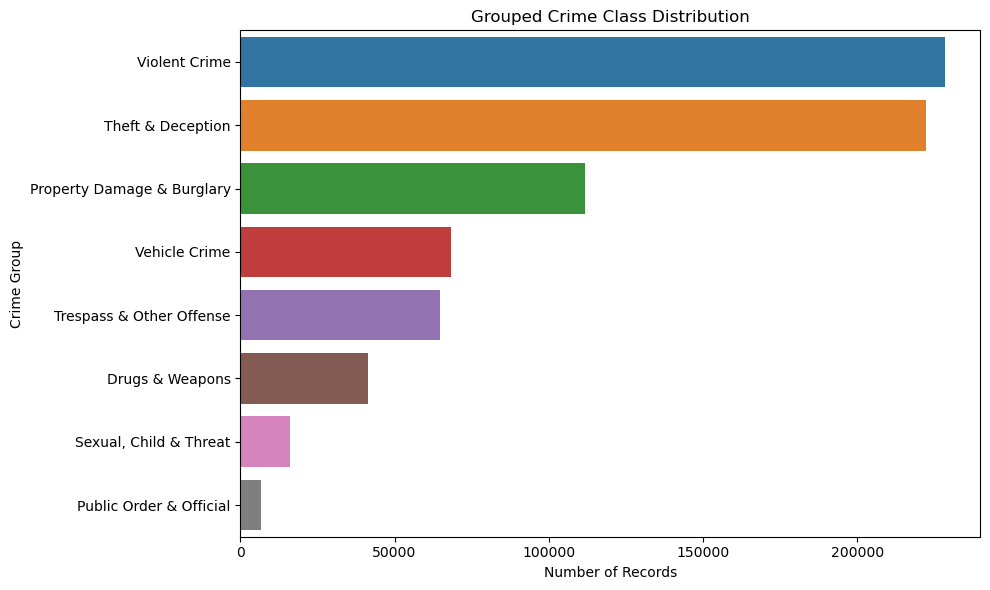

In [11]:
# Visualize the distribution of the grouped crime classes

plt.figure(figsize=(10, 6))

sns.barplot(
    x=group_counts.values,
    y=group_counts.index
)

plt.xlabel("Number of Records")
plt.ylabel("Crime Group")
plt.title("Grouped Crime Class Distribution")

plt.tight_layout()
plt.show()

In [12]:
# Find the size of the smallest crime class
# This value will be used as the target size for balancing

min_count = df["crime_group"].value_counts().min()

print("Smallest class size:", min_count)

Smallest class size: 6605


In [13]:
# Balance all crime groups by randomly selecting the same number
# of records from each class

balanced_df = (
    df.groupby("crime_group", group_keys=False)
      .apply(
          lambda x: x.sample(
              n=min_count,
              random_state=42
          )
      )
      .reset_index(drop=True)
)

In [14]:
# Shuffle the balanced dataset so that records from different
# crime groups are randomly distributed

balanced_df = balanced_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("Balanced dataset shape:", balanced_df.shape)

Balanced dataset shape: (52840, 23)


In [15]:
# Check whether all crime groups now contain the same number of records

balanced_counts = balanced_df["crime_group"].value_counts()

print(balanced_counts)

crime_group
Trespass & Other Offense      6605
Property Damage & Burglary    6605
Theft & Deception             6605
Drugs & Weapons               6605
Violent Crime                 6605
Vehicle Crime                 6605
Public Order & Official       6605
Sexual, Child & Threat        6605
Name: count, dtype: int64


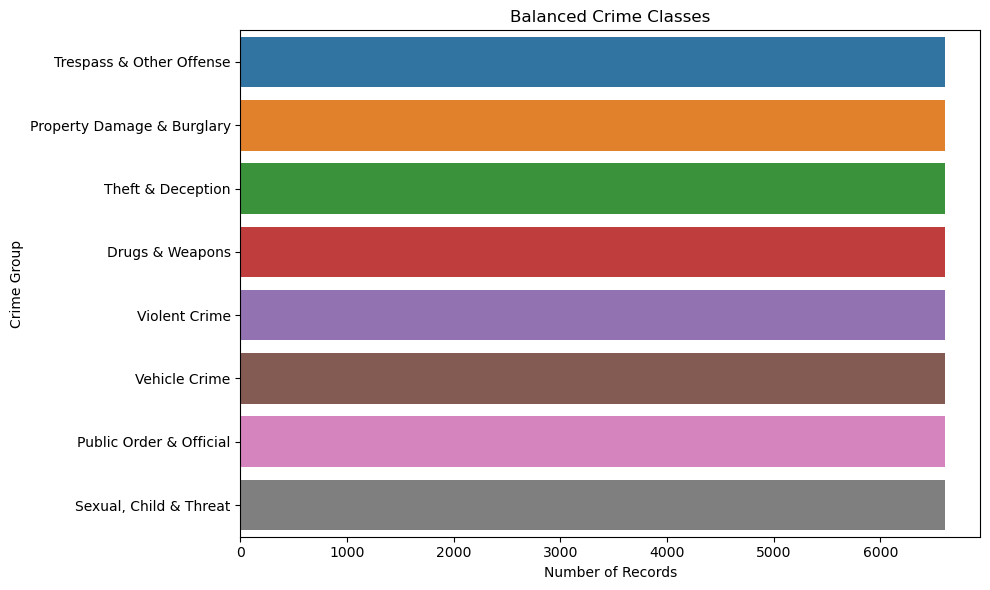

In [16]:
# Visualize the balanced crime class distribution

plt.figure(figsize=(10, 6))

sns.barplot(
    x=balanced_counts.values,
    y=balanced_counts.index
)

plt.xlabel("Number of Records")
plt.ylabel("Crime Group")
plt.title("Balanced Crime Classes")

plt.tight_layout()
plt.show()

In [17]:
# Convert the Date column into datetime format
# This allows us to extract useful time-based features

balanced_df["Date"] = pd.to_datetime(
    balanced_df["Date"],
    errors="coerce"
)

print(balanced_df["Date"].dtype)

C:\Users\aru12\AppData\Local\Temp\ipykernel_20468\3220349369.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  balanced_df["Date"] = pd.to_datetime(


datetime64[ns]


In [18]:
# Extract time-related features from the crime occurrence date

balanced_df["hour"] = balanced_df["Date"].dt.hour

balanced_df["day_of_week"] = balanced_df["Date"].dt.dayofweek

balanced_df["month"] = balanced_df["Date"].dt.month

balanced_df["year"] = balanced_df["Date"].dt.year

In [19]:
# Display the newly created time features

balanced_df[
    [
        "Date",
        "hour",
        "day_of_week",
        "month",
        "year"
    ]
].head()

,Date,hour,day_of_week,month,year
0,2025-12-06 13:00:00,13,5,12,2025
1,2024-12-25 23:00:00,23,2,12,2024
2,2024-01-01 13:56:00,13,0,1,2024
3,2023-12-15 20:49:00,20,4,12,2023
4,2025-05-24 09:12:00,9,5,5,2025


In [20]:
# Select and rename location-related and contextual features
# that will be used for crime classification

balanced_df["latitude"] = pd.to_numeric(
    balanced_df["Latitude"],
    errors="coerce"
)

balanced_df["longitude"] = pd.to_numeric(
    balanced_df["Longitude"],
    errors="coerce"
)

balanced_df["beat"] = balanced_df["Beat"]

balanced_df["district"] = balanced_df["District"]

balanced_df["ward"] = balanced_df["Ward"]

balanced_df["community_area"] = balanced_df["Community Area"]

balanced_df["location_description"] = balanced_df[
    "Location Description"
]

balanced_df["domestic"] = balanced_df["Domestic"]

In [21]:
# Check for missing values in the selected model features

feature_columns = [
    "hour",
    "day_of_week",
    "month",
    "year",
    "latitude",
    "longitude",
    "beat",
    "district",
    "ward",
    "community_area",
    "location_description",
    "domestic"
]

print(
    balanced_df[feature_columns].isnull().sum()
)

hour                      0
day_of_week               0
month                     0
year                      0
latitude                498
longitude               498
beat                      0
district                  0
ward                      1
community_area            1
location_description    110
domestic                  0
dtype: int64


In [22]:
# Remove records with missing values in the selected features

balanced_df = balanced_df.dropna(
    subset=feature_columns
).reset_index(drop=True)

print("Dataset after removing missing values:")
print(balanced_df.shape)

Dataset after removing missing values:
(52240, 35)


In [23]:
# Separate the input features into numerical and categorical variables

numerical_features = [
    "hour",
    "day_of_week",
    "month",
    "year",
    "latitude",
    "longitude"
]

categorical_features = [
    "beat",
    "district",
    "ward",
    "community_area",
    "location_description",
    "domestic"
]

all_features = numerical_features + categorical_features

In [24]:
# Create the input feature matrix X and target variable y

X = balanced_df[all_features].copy()

y = balanced_df["crime_group"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (52240, 12)
y shape: (52240,)


In [25]:
# Verify the distribution of the final target classes

print(y.value_counts())

crime_group
Violent Crime                 6581
Property Damage & Burglary    6580
Vehicle Crime                 6580
Public Order & Official       6561
Trespass & Other Offense      6555
Drugs & Weapons               6544
Theft & Deception             6429
Sexual, Child & Threat        6410
Name: count, dtype: int64


In [26]:
# Split the dataset into 80% training data and 20% testing data
# Stratification preserves the class distribution in both sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (41792, 12)
Testing data : (10448, 12)


In [27]:
# Check the crime class distribution in the training and testing sets

print("Training class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training class distribution:
crime_group
Violent Crime                 5265
Vehicle Crime                 5264
Property Damage & Burglary    5264
Public Order & Official       5249
Trespass & Other Offense      5244
Drugs & Weapons               5235
Theft & Deception             5143
Sexual, Child & Threat        5128
Name: count, dtype: int64

Testing class distribution:
crime_group
Violent Crime                 1316
Vehicle Crime                 1316
Property Damage & Burglary    1316
Public Order & Official       1312
Trespass & Other Offense      1311
Drugs & Weapons               1309
Theft & Deception             1286
Sexual, Child & Threat        1282
Name: count, dtype: int64


In [28]:
# Create cyclic representations of hour, day, and month
# This helps the models understand that time is cyclical

balanced_df["hour_sin"] = np.sin(
    2 * np.pi * balanced_df["hour"] / 24
)

balanced_df["hour_cos"] = np.cos(
    2 * np.pi * balanced_df["hour"] / 24
)

balanced_df["day_sin"] = np.sin(
    2 * np.pi * balanced_df["day_of_week"] / 7
)

balanced_df["day_cos"] = np.cos(
    2 * np.pi * balanced_df["day_of_week"] / 7
)

balanced_df["month_sin"] = np.sin(
    2 * np.pi * balanced_df["month"] / 12
)

balanced_df["month_cos"] = np.cos(
    2 * np.pi * balanced_df["month"] / 12
)

print("Cyclic time features created successfully.")

Cyclic time features created successfully.


In [29]:
# Define numerical features used for prediction

numerical_features = [
    "hour",
    "day_of_week",
    "month",
    "year",
    "latitude",
    "longitude",
    "hour_sin",
    "hour_cos",
    "day_sin",
    "day_cos",
    "month_sin",
    "month_cos"
]


# Define categorical location and contextual features

categorical_features = [
    "beat",
    "district",
    "ward",
    "community_area",
    "location_description",
    "domestic"
]

all_features = numerical_features + categorical_features

print("Total number of features:", len(all_features))
print("\nFeatures:")
print(all_features)

Total number of features: 18

Features:
['hour', 'day_of_week', 'month', 'year', 'latitude', 'longitude', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'beat', 'district', 'ward', 'community_area', 'location_description', 'domestic']


In [30]:
# Create the final input features and target variable

X = balanced_df[all_features].copy()

y = balanced_df["crime_group"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (52240, 18)
y shape: (52240,)


In [31]:
# Split the final feature set into 80% training and 20% testing data
# Stratification preserves the class distribution

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (41792, 18)
Testing data : (10448, 18)


In [32]:
# Check the target distribution after the train-test split

print("Training class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training class distribution:
crime_group
Violent Crime                 5265
Vehicle Crime                 5264
Property Damage & Burglary    5264
Public Order & Official       5249
Trespass & Other Offense      5244
Drugs & Weapons               5235
Theft & Deception             5143
Sexual, Child & Threat        5128
Name: count, dtype: int64

Testing class distribution:
crime_group
Violent Crime                 1316
Vehicle Crime                 1316
Property Damage & Burglary    1316
Public Order & Official       1312
Trespass & Other Offense      1311
Drugs & Weapons               1309
Theft & Deception             1286
Sexual, Child & Threat        1282
Name: count, dtype: int64


In [33]:
# Import tools required for preprocessing and ML pipelines

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [34]:
# Scale numerical features and convert categorical features
# into numerical one-hot encoded values

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            StandardScaler(),
            numerical_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


In [35]:
!pip install xgboost

In [36]:
# Import the base machine learning models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

print("ML models imported successfully.")

ML models imported successfully.


In [37]:
# Create the Logistic Regression pipeline

lr_model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                C=1.0,
                random_state=42
            )
        )
    ]
)

print("Logistic Regression model created.")

Logistic Regression model created.


In [38]:
# Train the Logistic Regression model

print("Training Logistic Regression...")

lr_model.fit(
    X_train,
    y_train
)

print("Logistic Regression training completed.")

Training Logistic Regression...
Logistic Regression training completed.


In [39]:
# Generate predictions using Logistic Regression

lr_pred = lr_model.predict(X_test)

print("Logistic Regression predictions generated.")

Logistic Regression predictions generated.


In [40]:
# Create the Decision Tree pipeline

dt_model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        (
            "model",
            DecisionTreeClassifier(
                max_depth=25,
                min_samples_split=10,
                min_samples_leaf=4,
                random_state=42
            )
        )
    ]
)

print("Decision Tree model created.")

Decision Tree model created.


In [41]:
# Train the Decision Tree model

print("Training Decision Tree...")

dt_model.fit(
    X_train,
    y_train
)

print("Decision Tree training completed.")

Training Decision Tree...
Decision Tree training completed.


In [42]:
# Generate predictions using Decision Tree

dt_pred = dt_model.predict(X_test)

print("Decision Tree predictions generated.")

Decision Tree predictions generated.


In [43]:
# Create the Random Forest pipeline

rf_model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=None,
                min_samples_split=5,
                min_samples_leaf=2,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("Random Forest model created.")

Random Forest model created.


In [44]:
# Train the Random Forest model

print("Training Random Forest...")

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest training completed.")

Training Random Forest...
Random Forest training completed.


In [45]:
# Generate predictions using Random Forest

rf_pred = rf_model.predict(X_test)

print("Random Forest predictions generated.")

Random Forest predictions generated.


In [46]:
# Convert the crime-group labels into numerical class labels
# required by XGBoost

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)

y_test_encoded = label_encoder.transform(y_test)

print("Crime classes:")
print(label_encoder.classes_)

Crime classes:
['Drugs & Weapons' 'Property Damage & Burglary' 'Public Order & Official'
 'Sexual, Child & Threat' 'Theft & Deception' 'Trespass & Other Offense'
 'Vehicle Crime' 'Violent Crime']


In [47]:
# Fit the preprocessing pipeline using training data
# and transform both training and testing features

X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape :", X_test_processed.shape)

Processed training shape: (41792, 548)
Processed testing shape : (10448, 548)


In [48]:
# Create the XGBoost multiclass classification model

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=len(label_encoder.classes_),
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

print("XGBoost model created.")

XGBoost model created.


In [49]:
# Train the XGBoost model

print("Training XGBoost...")

xgb_model.fit(
    X_train_processed,
    y_train_encoded
)

print("XGBoost training completed.")

Training XGBoost...
XGBoost training completed.


In [50]:
# Generate XGBoost predictions and convert them
# back to the original crime-group labels

xgb_pred_encoded = xgb_model.predict(
    X_test_processed
)

xgb_pred = label_encoder.inverse_transform(
    xgb_pred_encoded.astype(int)
)

print("XGBoost predictions generated.")

XGBoost predictions generated.


In [51]:
# Calculate sample weights so that each class receives
# appropriate importance during XGBoost training

from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train_encoded
)

print("Balanced sample weights created.")

Balanced sample weights created.


In [52]:
# Create the balanced XGBoost model

balanced_xgb_model = XGBClassifier(
    n_estimators=400,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=len(label_encoder.classes_),
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

print("Balanced XGBoost model created.")

Balanced XGBoost model created.


In [53]:
# Train XGBoost using balanced sample weights

print("Training Balanced XGBoost...")

balanced_xgb_model.fit(
    X_train_processed,
    y_train_encoded,
    sample_weight=sample_weights
)

print("Balanced XGBoost training completed.")

Training Balanced XGBoost...


Balanced XGBoost training completed.


In [54]:
# Generate predictions from the balanced XGBoost model

balanced_xgb_pred_encoded = balanced_xgb_model.predict(
    X_test_processed
)

balanced_xgb_pred = label_encoder.inverse_transform(
    balanced_xgb_pred_encoded.astype(int)
)

print("Balanced XGBoost predictions generated.")

Balanced XGBoost predictions generated.


In [55]:
# Import metrics used to evaluate the classification models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix
)

In [56]:
# Store predictions from all trained ML models

model_predictions = {
    "Logistic Regression": lr_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred,
    "Balanced XGBoost": balanced_xgb_pred
}

print("Predictions stored for all models.")

Predictions stored for all models.


In [57]:
# Calculate performance metrics for every base ML model

results = []

for model_name, predictions in model_predictions.items():

    results.append({

        "Model": model_name,

        "Accuracy": accuracy_score(
            y_test,
            predictions
        ),

        "Precision": precision_score(
            y_test,
            predictions,
            average="weighted",
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            predictions,
            average="weighted",
            zero_division=0
        ),

        "F1": f1_score(
            y_test,
            predictions,
            average="weighted",
            zero_division=0
        ),

        "Balanced Accuracy": balanced_accuracy_score(
            y_test,
            predictions
        ),

        "Macro F1": f1_score(
            y_test,
            predictions,
            average="macro",
            zero_division=0
        )
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1,Balanced Accuracy,Macro F1
0,Logistic Regression,0.357389,0.350975,0.357389,0.344428,0.357467,0.344561
1,Decision Tree,0.302259,0.301008,0.302259,0.299562,0.302485,0.299650
2,Random Forest,0.372320,0.364100,0.372320,0.358860,0.372381,0.358978
3,XGBoost,0.377680,0.374284,0.377680,0.365883,0.377627,0.365954
4,Balanced XGBoost,0.377106,0.372851,0.377106,0.365404,0.377108,0.365494


In [59]:
# Check detailed class-wise performance of the current XGBoost model

print("XGBoost Classification Report")
print("=" * 70)

print(
    classification_report(
        y_test,
        xgb_pred,
        zero_division=0
    )
)

XGBoost Classification Report
                            precision    recall  f1-score   support

           Drugs & Weapons       0.43      0.51      0.47      1309
Property Damage & Burglary       0.34      0.20      0.25      1316
   Public Order & Official       0.46      0.38      0.42      1312
    Sexual, Child & Threat       0.36      0.37      0.36      1282
         Theft & Deception       0.40      0.37      0.38      1286
  Trespass & Other Offense       0.28      0.21      0.24      1311
             Vehicle Crime       0.37      0.68      0.48      1316
             Violent Crime       0.35      0.31      0.33      1316

                  accuracy                           0.38     10448
                 macro avg       0.37      0.38      0.37     10448
              weighted avg       0.37      0.38      0.37     10448



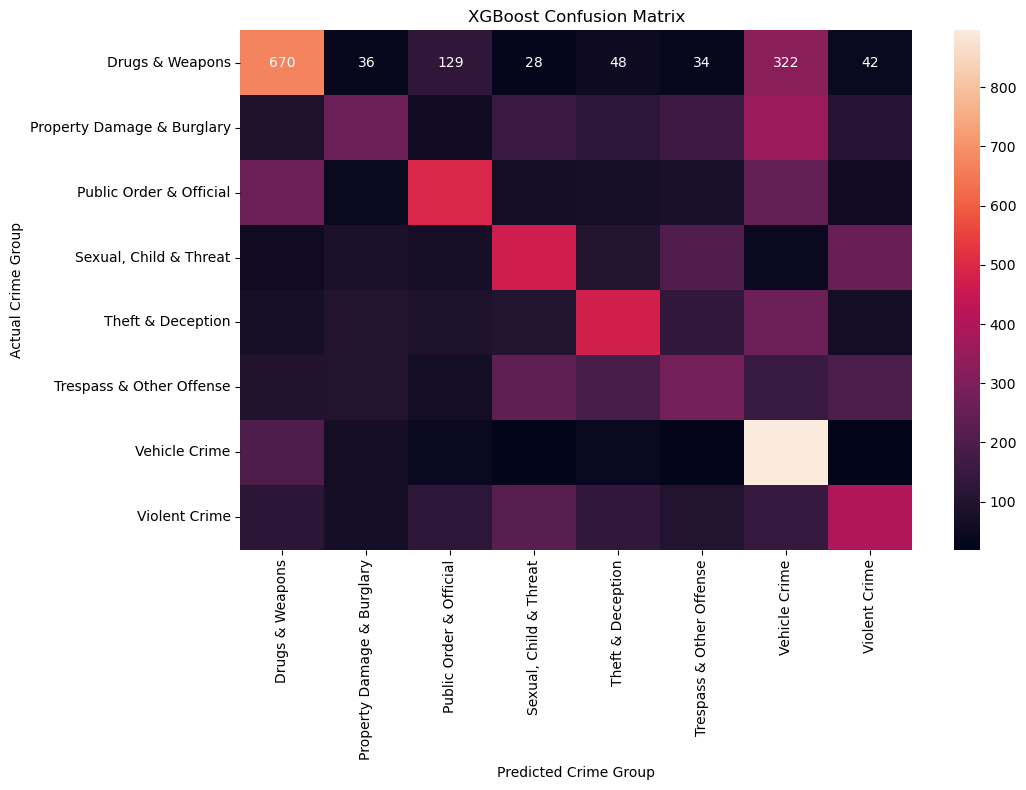

In [60]:
# Visualize which crime groups are being confused by XGBoost

cm_xgb = confusion_matrix(
    y_test,
    xgb_pred,
    labels=label_encoder.classes_
)

plt.figure(figsize=(11, 8))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Crime Group")
plt.ylabel("Actual Crime Group")
plt.title("XGBoost Confusion Matrix")

plt.tight_layout()
plt.show()

In [61]:
# Create additional time-based features

balanced_df["is_weekend"] = (
    balanced_df["day_of_week"] >= 5
).astype(int)

balanced_df["is_night"] = (
    (balanced_df["hour"] >= 22) |
    (balanced_df["hour"] < 6)
).astype(int)

balanced_df["is_morning"] = (
    (balanced_df["hour"] >= 6) &
    (balanced_df["hour"] < 12)
).astype(int)

balanced_df["is_afternoon"] = (
    (balanced_df["hour"] >= 12) &
    (balanced_df["hour"] < 18)
).astype(int)

balanced_df["is_evening"] = (
    (balanced_df["hour"] >= 18) &
    (balanced_df["hour"] < 22)
).astype(int)

print("Additional time features created.")

Additional time features created.


In [62]:
# Define the improved numerical features

numerical_features = [
    "hour",
    "day_of_week",
    "month",
    "year",
    "latitude",
    "longitude",

    # Cyclic time features
    "hour_sin",
    "hour_cos",
    "day_sin",
    "day_cos",
    "month_sin",
    "month_cos"
]


# Define additional categorical/context features

categorical_features = [
    "beat",
    "district",
    "ward",
    "community_area",
    "location_description",
    "domestic",

    # Time-category features
    "is_weekend",
    "is_night",
    "is_morning",
    "is_afternoon",
    "is_evening"
]

all_features = numerical_features + categorical_features

print("Total features:", len(all_features))

Total features: 23


In [63]:
# Recreate the input features and target using the improved feature set

X = balanced_df[all_features].copy()

y = balanced_df["crime_group"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (52240, 23)
y shape: (52240,)


In [64]:
# Create a fresh 80/20 stratified split using the improved features

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (41792, 23)
Testing data : (10448, 23)


In [65]:
# Recreate the preprocessing pipeline for the improved feature set

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            StandardScaler(),
            numerical_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

print("Updated preprocessing pipeline created.")

Updated preprocessing pipeline created.


In [66]:
# Transform the updated training and testing features

X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape :", X_test_processed.shape)

Processed training shape: (41792, 558)
Processed testing shape : (10448, 558)


In [67]:
# Create a more thoroughly trained XGBoost model

xgb_improved = XGBClassifier(
    n_estimators=600,
    max_depth=10,
    learning_rate=0.03,
    min_child_weight=2,
    subsample=0.85,
    colsample_bytree=0.85,

    objective="multi:softmax",
    num_class=len(label_encoder.classes_),

    eval_metric="mlogloss",

    random_state=42,
    n_jobs=-1
)

print("Improved XGBoost model created.")

Improved XGBoost model created.


In [68]:
# Train the improved XGBoost model

print("Training improved XGBoost...")

xgb_improved.fit(
    X_train_processed,
    y_train_encoded
)

print("Improved XGBoost training completed.")

Training improved XGBoost...
Improved XGBoost training completed.


In [69]:
# Generate predictions from the improved XGBoost model

xgb_improved_pred_encoded = xgb_improved.predict(
    X_test_processed
)

xgb_improved_pred = label_encoder.inverse_transform(
    xgb_improved_pred_encoded.astype(int)
)

print("Predictions generated.")

Predictions generated.


In [70]:
# Evaluate the improved XGBoost model

improved_accuracy = accuracy_score(
    y_test,
    xgb_improved_pred
)

improved_precision = precision_score(
    y_test,
    xgb_improved_pred,
    average="weighted",
    zero_division=0
)

improved_recall = recall_score(
    y_test,
    xgb_improved_pred,
    average="weighted",
    zero_division=0
)

improved_f1 = f1_score(
    y_test,
    xgb_improved_pred,
    average="weighted",
    zero_division=0
)

improved_balanced_accuracy = balanced_accuracy_score(
    y_test,
    xgb_improved_pred
)

improved_macro_f1 = f1_score(
    y_test,
    xgb_improved_pred,
    average="macro",
    zero_division=0
)

print("Improved XGBoost Results")
print("=" * 50)

print("Accuracy:", improved_accuracy)
print("Precision:", improved_precision)
print("Recall:", improved_recall)
print("F1:", improved_f1)
print("Balanced Accuracy:", improved_balanced_accuracy)
print("Macro F1:", improved_macro_f1)

Improved XGBoost Results
Accuracy: 0.37566998468606433
Precision: 0.3700369592748008
Recall: 0.37566998468606433
F1: 0.36434368491971136
Balanced Accuracy: 0.3756103354467988
Macro F1: 0.364392546124674
